librerias

In [1]:
# Manejo de directorios y rutas
import os

# Computación numérica y manejo de matrices
import numpy as np

# Manejo y preprocesamiento de datos
import pandas as pd

# Librerías para graficación
from matplotlib import pyplot

# Mostrar gráficos dentro del cuadernillo
%matplotlib inline

tratamiento del dataset

In [3]:
datos = pd.read_csv("dataset_4/diabetes_dataset.csv")

# Mostrar dimensiones
print("Número de ejemplos:", datos.shape[0])
print("Número de características/columnas:", datos.shape[1])

# Mostrar nombres de las columnas
print("\nColumnas del dataset:")
print(datos.columns.tolist())

# Mostrar las primeras filas
datos.head()

Número de ejemplos: 100000
Número de características/columnas: 31

Columnas del dataset:
['age', 'gender', 'ethnicity', 'education_level', 'income_level', 'employment_status', 'smoking_status', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'glucose_fasting', 'glucose_postprandial', 'insulin_level', 'hba1c', 'diabetes_risk_score', 'diabetes_stage', 'diagnosed_diabetes']


,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


In [4]:
print(datos['diagnosed_diabetes'].value_counts())

diagnosed_diabetes
1    59998
0    40002
Name: count, dtype: int64


transformacion de variables de tipo texto a tipo binario con One-Hot Encoding


In [5]:
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  str    
 2   ethnicity                           100000 non-null  str    
 3   education_level                     100000 non-null  str    
 4   income_level                        100000 non-null  str    
 5   employment_status                   100000 non-null  str    
 6   smoking_status                      100000 non-null  str    
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_hours_per_day           10

In [6]:
columnas_texto = datos.select_dtypes(include="str").columns

for columna in columnas_texto:
    print("\n" + "=" * 50)
    print(columna)
    print("=" * 50)
    print(datos[columna].value_counts())


gender
gender
Female    50216
Male      47771
Other      2013
Name: count, dtype: int64

ethnicity
ethnicity
White       44997
Hispanic    20103
Black       17986
Asian       11865
Other        5049
Name: count, dtype: int64

education_level
education_level
Highschool      44891
Graduate        35037
Postgraduate    14972
No formal        5100
Name: count, dtype: int64

income_level
income_level
Middle          35152
Lower-Middle    25150
Upper-Middle    19866
Low             14830
High             5002
Name: count, dtype: int64

employment_status
employment_status
Employed      60175
Retired       21761
Unemployed    11918
Student        6146
Name: count, dtype: int64

smoking_status
smoking_status
Never      59813
Current    20176
Former     20011
Name: count, dtype: int64

diabetes_stage
diabetes_stage
Type 2          59774
Pre-Diabetes    31845
No Diabetes      7981
Gestational       278
Type 1            122
Name: count, dtype: int64


copia del dataset

In [4]:
# Crear una copia del dataset original
datos_modelo = datos.copy()

print("Dataset original:", datos.shape)
print("Copia para el modelo:", datos_modelo.shape)

Dataset original: (100000, 31)
Copia para el modelo: (100000, 31)


In [7]:
datos_modelo.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  str    
 2   ethnicity                           100000 non-null  str    
 3   education_level                     100000 non-null  str    
 4   income_level                        100000 non-null  str    
 5   employment_status                   100000 non-null  str    
 6   smoking_status                      100000 non-null  str    
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_hours_per_day           10

eliminamos una variable comlicada

In [8]:
# Eliminar la variable que no utilizaremos
datos_modelo = datos_modelo.drop(columns=["diabetes_stage"])

In [9]:
print("Copia para el modelo:", datos_modelo.shape)

Copia para el modelo: (100000, 30)


aplicamos division de columnas o one hot encoding

In [10]:
# Variables categóricas que vamos a transformar
columnas_categoricas = [
    "gender",
    "ethnicity",
    "education_level",
    "income_level",
    "employment_status",
    "smoking_status"
]

# Convertir variables categóricas a variables numéricas
datos_modelo = pd.get_dummies(
    datos_modelo,
    columns=columnas_categoricas,
    dtype=int
)

In [12]:
print("Copia para el modelo:", datos_modelo.shape)

Copia para el modelo: (100000, 48)


In [13]:
datos_modelo.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 48 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   alcohol_consumption_per_week        100000 non-null  int64  
 2   physical_activity_minutes_per_week  100000 non-null  int64  
 3   diet_score                          100000 non-null  float64
 4   sleep_hours_per_day                 100000 non-null  float64
 5   screen_time_hours_per_day           100000 non-null  float64
 6   family_history_diabetes             100000 non-null  int64  
 7   hypertension_history                100000 non-null  int64  
 8   cardiovascular_history              100000 non-null  int64  
 9   bmi                                 100000 non-null  float64
 10  waist_to_hip_ratio                  100000 non-null  float64
 11  systolic_bp                         10

cargamos los datos a x, y

In [11]:
X = datos_modelo.drop(columns=["diagnosed_diabetes"])
y = datos_modelo["diagnosed_diabetes"]
m = y.size
print("Forma de X:", X.shape)
print("Forma de y:", y.shape)
print("Número de ejemplos:", m)

Forma de X: (100000, 47)
Forma de y: (100000,)
Número de ejemplos: 100000


divion train - test

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (80000, 47)
X_test: (20000, 47)
y_train: (80000,)
y_test: (20000,)


In [13]:
print("Distribución original:")
print(y.value_counts())
print(y.value_counts(normalize=True))

print("\nDistribución en TRAIN:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

print("\nDistribución en TEST:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True))

Distribución original:
diagnosed_diabetes
1    59998
0    40002
Name: count, dtype: int64
diagnosed_diabetes
1    0.59998
0    0.40002
Name: proportion, dtype: float64

Distribución en TRAIN:
diagnosed_diabetes
1    47998
0    32002
Name: count, dtype: int64
diagnosed_diabetes
1    0.599975
0    0.400025
Name: proportion, dtype: float64

Distribución en TEST:
diagnosed_diabetes
1    12000
0     8000
Name: count, dtype: int64
diagnosed_diabetes
1    0.6
0    0.4
Name: proportion, dtype: float64


aplicacion de SMOTE

In [14]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    sampling_strategy=0.95,
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [15]:
print("Distribución DESPUÉS de SMOTE:")
print(y_train_smote.value_counts())

print("\nPorcentajes:")
print(y_train_smote.value_counts(normalize=True) * 100)

print("\nForma antes de SMOTE:")
print(X_train.shape)

print("\nForma después de SMOTE:")
print(X_train_smote.shape)

Distribución DESPUÉS de SMOTE:
diagnosed_diabetes
1    47998
0    45598
Name: count, dtype: int64

Porcentajes:
diagnosed_diabetes
1    51.282106
0    48.717894
Name: proportion, dtype: float64

Forma antes de SMOTE:
(80000, 47)

Forma después de SMOTE:
(93596, 47)


comensamos con el modelo de regresion

funcion de normalizacion

In [16]:
def featureNormalize(X):
    X_norm = X.copy()

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)

    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [17]:
X_train_norm, mu, sigma = featureNormalize(X_train_smote)

print("X_train_smote:", X_train_smote.shape)
print("X_train_norm:", X_train_norm.shape)

X_train_smote: (93596, 47)
X_train_norm: (93596, 47)


In [21]:
X_test_norm = (X_test - mu) / sigma

print("X_test:", X_test.shape)
print("X_test_norm:", X_test_norm.shape)

X_test: (20000, 47)
X_test_norm: (20000, 47)


funcion sigmoID

In [18]:
def sigmoid(z):
    # Calcula la función sigmoide
    z = np.array(z)

    g = 1 / (1 + np.exp(-z))

    return g

In [19]:
z = [-100, 0.5, 1000000]
g = sigmoid(z)

print('g(', z, ') = ', g)

g( [-100, 0.5, 1000000] ) =  [3.72007598e-44 6.22459331e-01 1.00000000e+00]


agregamos la columna de 1

In [22]:
X_train_final = np.concatenate(
    [np.ones((X_train_norm.shape[0], 1)), X_train_norm],
    axis=1
)

X_test_final = np.concatenate(
    [np.ones((X_test_norm.shape[0], 1)), X_test_norm],
    axis=1
)

In [30]:
print("X_test:", X_train_final.shape)
print("X_test_norm:", X_test_final.shape)

X_test: (93596, 48)
X_test_norm: (20000, 48)


funcion de costo

In [24]:
def calcularCosto(theta, X, y):
    # Inicializar algunos valores utiles
    m = y.size  # numero de ejemplos de entrenamiento

    J = 0
    h = sigmoid(X.dot(theta.T))
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))

    return J

descenso por gradiente 

In [25]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)

        J_history.append(calcularCosto(theta, X, y))
    return theta, J_history

coheficientes de aprendizaje

In [27]:
# Tasa de aprendizaje
alpha = 0.001

# Número de iteraciones
num_iters = 20000

# Inicializar theta
theta = np.zeros(X_train_final.shape[1])

# Entrenar el modelo
theta, J_history = descensoGradiente(
    theta,
    X_train_final,
    y_train_smote,
    alpha,
    num_iters
)

print("Theta calculado:")
print(theta)

Theta calculado:
[ 0.1251551   0.03872778  0.0235963  -0.04267128 -0.00812014 -0.00501702
  0.00219608  0.12022662  0.04077837  0.04621921  0.0236666   0.01747261
  0.01442182  0.0035747   0.00187715 -0.00121887 -0.01359095  0.01854496
  0.00743944  0.53879706  0.93375264 -0.00162988  1.20055759  0.06895165
  0.20183907  0.20600819  0.06983185  0.137517    0.16270104  0.179718
  0.0983162   0.21552615  0.20492267  0.21211861  0.09654788  0.1394602
  0.11053484  0.1578884   0.19076629  0.21241787  0.16987673  0.21461447
  0.16415984  0.09906395  0.14521755  0.16501961  0.16545037  0.20404529]


grafica de costo

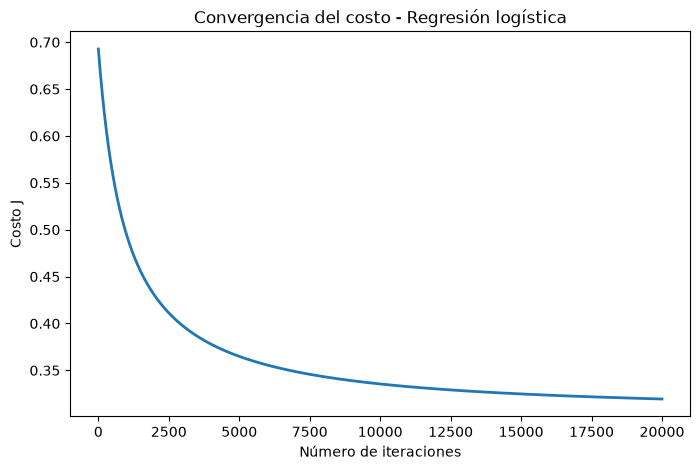

In [28]:
pyplot.figure(figsize=(8, 5))

pyplot.plot(
    np.arange(len(J_history)),
    J_history,
    lw=2
)

pyplot.xlabel("Número de iteraciones")
pyplot.ylabel("Costo J")
pyplot.title("Convergencia del costo - Regresión logística")

pyplot.show()

In [32]:
# Calcular las probabilidades para los datos de prueba
probabilidades_test = sigmoid(X_test_final.dot(theta))

print("Primeras 10 probabilidades:")
print(probabilidades_test[:10])

Primeras 10 probabilidades:
[0.30998146 0.91823898 0.05554539 0.22420067 0.9566686  0.30218104
 0.4424632  0.63692653 0.28974984 0.82841144]


In [33]:
# Umbral de clasificación
umbral = 0.5

# Convertir probabilidades en clases 0 o 1
y_pred_test = (probabilidades_test >= umbral).astype(int)

print("Primeras 20 predicciones:")
print(y_pred_test[:20])

print("\nPrimeros 20 valores reales:")
print(y_test[:20])

Primeras 20 predicciones:
[0 1 0 0 1 0 0 1 0 1 1 0 1 1 0 1 1 1 0 0]

Primeros 20 valores reales:
66593    0
52573    1
76795    0
99689    0
41313    1
41705    0
17021    0
59670    1
82740    0
64861    1
71281    1
89530    0
36243    1
379      0
8370     1
43991    1
49579    1
73147    1
7116     0
33540    1
Name: diagnosed_diabetes, dtype: int64


In [34]:
print("Distribución de las predicciones:")
print(pd.Series(y_pred_test).value_counts())

print("\nDistribución real del conjunto de prueba:")
print(pd.Series(y_test).value_counts())

Distribución de las predicciones:
1    12021
0     7979
Name: count, dtype: int64

Distribución real del conjunto de prueba:
diagnosed_diabetes
1    12000
0     8000
Name: count, dtype: int64


In [35]:
aciertos = np.sum(y_pred_test == y_test)

accuracy = (aciertos / len(y_test)) * 100

print("Total de ejemplos de prueba:", len(y_test))
print("Predicciones correctas:", aciertos)
print(f"Accuracy: {accuracy:.2f}%")

Total de ejemplos de prueba: 20000
Predicciones correctas: 17209
Accuracy: 86.05%
